# Clasificador de Rango Etario — UTKFace

Clasificación multiclase (5 clases) a partir de imágenes de rostros, implementado en **PyTorch** y **TensorFlow/Keras**.

**Rangos etarios:**

| Clase | Rango | Etiqueta |
|---|---|---|
| 0 | 0–12 | niño |
| 1 | 13–19 | adolescente |
| 2 | 20–35 | joven |
| 3 | 36–59 | adulto |
| 4 | 60+ | viejo |

> ## 📌 Banco de entrenamiento: carpeta única UTKFace (balanceo por muestreo, sin subcarpetas)
>
> Este notebook entrena leyendo **directamente** desde la carpeta original descargada, sin subcarpetas por clase (así no hay imágenes duplicadas en el repo):
> - Carpeta: `./UTKFace_data/UTKFace`
> - La etiqueta se calcula en Python a partir del **nombre de archivo** (`[edad]_[género]_[raza]_[fecha].jpg`), usando `parse_age_from_filename` + `age_to_bucket`.
> - Para mantener las clases balanceadas, se cuenta cuántas imágenes hay por clase y se **muestrea aleatoriamente** (semilla fija) el mínimo común (`cap`) de cada una — igual N° de imágenes por clase, sin necesidad de `class_weight` / `WeightedRandomSampler`.
>
> 👉 La versión entrenada sobre el banco **completo/desbalanceado** (23.705 imágenes) y sus resultados están en `clasificador_edad_utkface_RESULTADOS_completo.ipynb`.

## 0. Descarga del dataset (UTKFace)

**Opción A — Kaggle API (recomendado):**

```bash
pip install kaggle
# 1. Crea una cuenta en kaggle.com si no tienes
# 2. Ve a kaggle.com/settings -> API -> "Create New Token" (descarga kaggle.json)
# 3. Coloca kaggle.json en ~/.kaggle/kaggle.json (Linux/Mac) o C:\Users\<usuario>\.kaggle\kaggle.json (Windows)

kaggle datasets download -d jangedoo/utkface-new
unzip utkface-new.zip -d ./UTKFace_data
```

**Opción B — Descarga manual:**

1. Ve a https://www.kaggle.com/datasets/jangedoo/utkface-new
2. Descarga el .zip (botón Download)
3. Descomprime y deja la carpeta de imágenes en `./UTKFace_data/UTKFace/` (debe contener directamente los .jpg, sin subcarpetas extra)

**Estructura esperada:**
```
UTKFace_data/
  UTKFace/
    1_0_0_20161219140623097.jpg
    2_1_3_20170109150557335.jpg
    ...
```

El nombre de cada archivo sigue el formato `[edad]_[género]_[raza]_[fecha].jpg`. Solo usaremos el campo `edad`.

In [13]:
!pip install pandas matplotlib seaborn scikit-learn torch tensorflow pillow

In [14]:
# --- Configuración general ---
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "./UTKFace_data/UTKFace"     # carpeta única con todas las imágenes (sin subcarpetas por clase)
IMG_SIZE = 64                          # tamaño al que se redimensionan las imágenes
BATCH_SIZE = 32
SEED = 42

np.random.seed(SEED)

In [15]:
# --- Definición de los rangos etarios ---
CLASS_NAMES = ["nino", "adolescente", "joven", "adulto", "viejo"]

def age_to_bucket(age: int) -> int:
    """Convierte una edad entera al índice de clase (0-4) según los rangos definidos."""
    if age <= 12:
        return 0  # nino
    elif age <= 19:
        return 1  # adolescente
    elif age <= 35:
        return 2  # joven
    elif age <= 59:
        return 3  # adulto
    else:
        return 4  # viejo

def parse_age_from_filename(filename: str):
    """Extrae la edad desde un nombre de archivo tipo '23_0_1_2017...jpg'. Devuelve None si no calza el formato."""
    base = os.path.basename(filename)
    match = re.match(r"^(\d+)_\d+_\d+_.+\.jpg$", base)
    if match is None:
        return None
    return int(match.group(1))

In [16]:
# --- Construcción del dataframe desde la carpeta única UTKFace ---
# La etiqueta se calcula parseando la edad del NOMBRE DE ARCHIVO (no hay subcarpetas por clase).
# Para balancear sin duplicar imágenes en disco: se muestrea aleatoriamente el mínimo común (cap)
# de imágenes por clase, con semilla fija para reproducibilidad.
all_fps = glob.glob(os.path.join(DATA_DIR, "*.jpg"))
if len(all_fps) == 0:
    raise FileNotFoundError(
        f"No hay imágenes en '{DATA_DIR}'. Revisa que la carpeta UTKFace exista con los .jpg "
        "directamente adentro (ver celda de descarga del dataset)."
    )

records_by_class = {i: [] for i in range(len(CLASS_NAMES))}
skipped = 0
for fp in all_fps:
    age = parse_age_from_filename(fp)
    if age is None:
        skipped += 1
        continue
    records_by_class[age_to_bucket(age)].append(fp)

print(f"Imágenes totales encontradas: {len(all_fps)}  |  Descartadas (nombre no calza el formato): {skipped}")
print("Disponibles por clase (antes de balancear):")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {len(records_by_class[i])}")

cap = min(len(fps) for fps in records_by_class.values())
print(f"\nCap por clase (mínimo común): {cap}")

rng = np.random.RandomState(SEED)
records = []
for label_idx, fps in records_by_class.items():
    sampled = rng.choice(fps, size=cap, replace=False)
    for fp in sampled:
        records.append({"filepath": fp, "label": label_idx})

df = pd.DataFrame(records, columns=["filepath", "label"])
print(f"\nImágenes usadas para entrenar (balanceado): {len(df)}")
print("Por clase:")
print(df["label"].value_counts().sort_index().rename(index=lambda i: CLASS_NAMES[i]))
df.head()

Imágenes totales encontradas: 23708  |  Descartadas (nombre no calza el formato): 3
Disponibles por clase (antes de balancear):
  nino: 3413
  adolescente: 1180
  joven: 10514
  adulto: 5910
  viejo: 2688

Cap por clase (mínimo común): 1180

Imágenes usadas para entrenar (balanceado): 5900
Por clase:
label
nino           1180
adolescente    1180
joven          1180
adulto         1180
viejo          1180
Name: count, dtype: int64


,filepath,label
0,./UTKFace_data/UTKFace\3_0_0_20170109192415151...,0
1,./UTKFace_data/UTKFace\2_1_2_20161219160232453...,0
2,./UTKFace_data/UTKFace\11_0_0_2017011022474203...,0
3,./UTKFace_data/UTKFace\1_0_2_20161219203236876...,0
4,./UTKFace_data/UTKFace\6_1_2_20161219201340515...,0


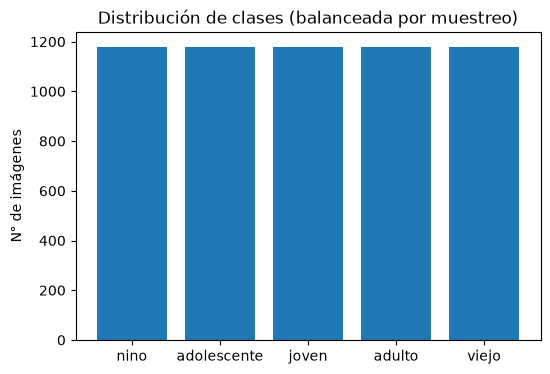

label
nino           1180
adolescente    1180
joven          1180
adulto         1180
viejo          1180
Name: count, dtype: int64


In [17]:
# --- Distribución de clases ---
counts = df["label"].value_counts().reindex(range(len(CLASS_NAMES)), fill_value=0)
plt.figure(figsize=(6, 4))
plt.bar(CLASS_NAMES, counts.values)
plt.title("Distribución de clases (balanceada por muestreo)")
plt.ylabel("N° de imágenes")
plt.show()

print(counts.rename(index=lambda i: CLASS_NAMES[i]))
# Balanceado por muestreo (cap = mínimo común entre clases) -> barras del mismo alto.

In [18]:
# --- Split train / val / test (estratificado por clase) ---
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}  |  Test: {len(test_df)}")

Train: 4130  |  Val: 885  |  Test: 885


## Parte A — PyTorch

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import time
import torchvision.transforms as T

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

class UTKFaceDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, row["label"]

train_ds = UTKFaceDataset(train_df, transform)
val_ds = UTKFaceDataset(val_df, transform)
test_ds = UTKFaceDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

Device: cpu


In [20]:
# --- Arquitectura CNN simple ---
class AgeCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        # IMG_SIZE=64 -> tras 3 poolings de /2: 64 -> 32 -> 16 -> 8
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

model_pt = AgeCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model_pt)

AgeCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=5, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)


In [21]:
# --- Entrenamiento (PyTorch) ---
ti1=time.time()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_pt.parameters(), lr=1e-3)
EPOCHS = 10

def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(train):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if train:
                optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
    return total_loss / total, correct / total

history_pt = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model_pt, train_loader, train=True)
    va_loss, va_acc = run_epoch(model_pt, val_loader, train=False)
    history_pt["train_loss"].append(tr_loss); history_pt["train_acc"].append(tr_acc)
    history_pt["val_loss"].append(va_loss); history_pt["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | val_loss={va_loss:.4f} val_acc={va_acc:.4f}")


tf1=time.time()
t_total = tf1 - ti1
print(f"\nTiempo total de entrenamiento (PyTorch): {t_total:.2f} segundos")

Epoch 1/10 | train_loss=1.4336 train_acc=0.3683 | val_loss=1.1684 val_acc=0.4983
Epoch 2/10 | train_loss=1.1441 train_acc=0.5099 | val_loss=1.0212 val_acc=0.5593
Epoch 3/10 | train_loss=1.0299 train_acc=0.5508 | val_loss=1.0335 val_acc=0.5480
Epoch 4/10 | train_loss=0.9591 train_acc=0.5923 | val_loss=0.9336 val_acc=0.6090
Epoch 5/10 | train_loss=0.8965 train_acc=0.6203 | val_loss=0.9161 val_acc=0.5932
Epoch 6/10 | train_loss=0.8381 train_acc=0.6433 | val_loss=0.9067 val_acc=0.6124
Epoch 7/10 | train_loss=0.7763 train_acc=0.6659 | val_loss=0.8703 val_acc=0.6102
Epoch 8/10 | train_loss=0.7366 train_acc=0.6838 | val_loss=0.8739 val_acc=0.6181
Epoch 9/10 | train_loss=0.6600 train_acc=0.7259 | val_loss=0.9023 val_acc=0.6463
Epoch 10/10 | train_loss=0.6243 train_acc=0.7351 | val_loss=0.8917 val_acc=0.6294

Tiempo total de entrenamiento (PyTorch): 281.14 segundos


              precision    recall  f1-score   support

        nino       0.83      0.86      0.84       177
 adolescente       0.63      0.42      0.50       177
       joven       0.48      0.62      0.54       177
      adulto       0.53      0.51      0.52       177
       viejo       0.72      0.75      0.74       177

    accuracy                           0.63       885
   macro avg       0.64      0.63      0.63       885
weighted avg       0.64      0.63      0.63       885



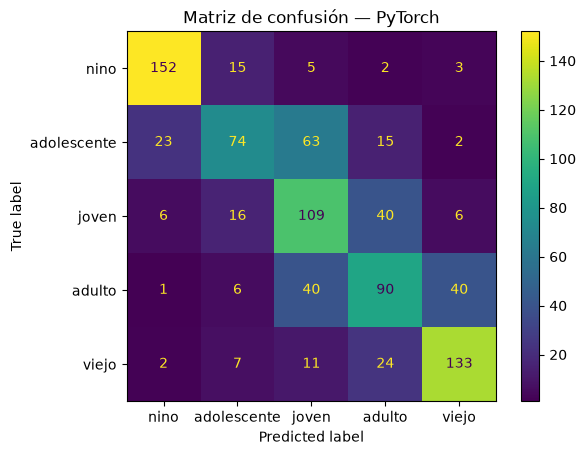

In [22]:
# --- Evaluación en test (PyTorch) ---
model_pt.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model_pt(imgs)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — PyTorch")
plt.show()

## Parte B — TensorFlow / Keras

In [23]:
import tensorflow as tf

def load_and_preprocess(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img, label

def make_tf_dataset(dataframe, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((dataframe["filepath"].values, dataframe["label"].values))
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds_tf = make_tf_dataset(train_df, shuffle=True)
val_ds_tf = make_tf_dataset(val_df)
test_ds_tf = make_tf_dataset(test_df)

In [24]:
# --- Arquitectura CNN equivalente, en Keras ---
model_tf = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation="softmax"),
])

model_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model_tf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 548,645 (2.09 MB)

 Trainable params: 548,645 (2.09 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# --- Entrenamiento (Keras) ---
ti2=time.time()
EPOCHS_TF = 10
history_tf = model_tf.fit(train_ds_tf, validation_data=val_ds_tf, epochs=EPOCHS_TF)

tf2=time.time()
t_total = tf2 - ti2
print(f"\nTiempo total de entrenamiento (Keras): {t_total:.2f} segundos")

Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.2918 - loss: 1.5331 - val_accuracy: 0.3582 - val_loss: 1.4009
Epoch 2/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.4852 - loss: 1.1953 - val_accuracy: 0.5401 - val_loss: 1.0747
Epoch 3/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 12s 62ms/step - accuracy: 0.5581 - loss: 1.0670 - val_accuracy: 0.5808 - val_loss: 0.9825
Epoch 4/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.5966 - loss: 0.9708 - val_accuracy: 0.5706 - val_loss: 0.9685
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.6111 - loss: 0.9135 - val_accuracy: 0.6249 - val_loss: 0.9004
Epoch 6/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 10s 65ms/step - accuracy: 0.6448 - loss: 0.8492 - val_accuracy: 0.6316 - val_loss: 0.9007
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.6642 - loss: 0.8160 - val_accuracy: 0.6136 - val_loss: 0.8962
Epoch 8/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step - accuracy: 0.6855 - loss: 0.7413 - val

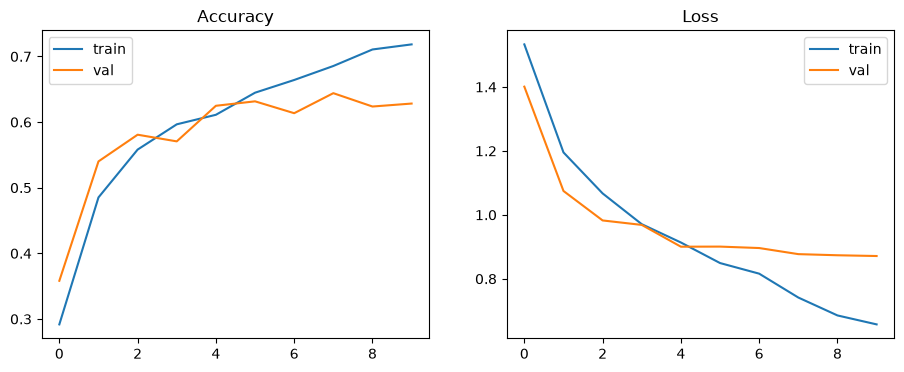

In [26]:
# --- Curvas de entrenamiento (Keras) ---
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history_tf.history["accuracy"], label="train")
axes[0].plot(history_tf.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy"); axes[0].legend()
axes[1].plot(history_tf.history["loss"], label="train")
axes[1].plot(history_tf.history["val_loss"], label="val")
axes[1].set_title("Loss"); axes[1].legend()
plt.show()

              precision    recall  f1-score   support

        nino       0.86      0.82      0.84       177
 adolescente       0.60      0.52      0.56       177
       joven       0.51      0.62      0.56       177
      adulto       0.56      0.46      0.50       177
       viejo       0.71      0.82      0.76       177

    accuracy                           0.65       885
   macro avg       0.65      0.65      0.64       885
weighted avg       0.65      0.65      0.64       885



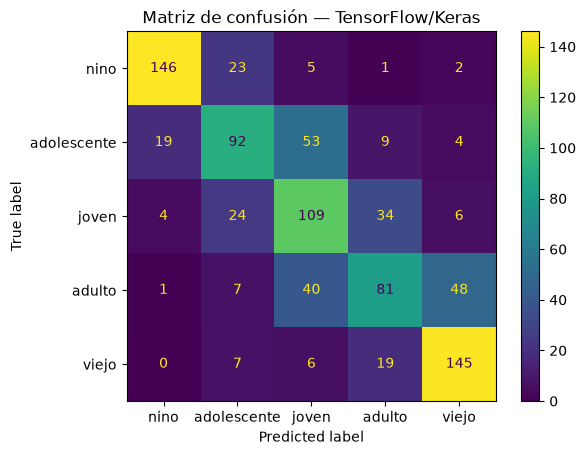

In [27]:
# --- Evaluación en test (Keras) ---
y_true_tf, y_pred_tf = [], []
for imgs, labels in test_ds_tf:
    preds = model_tf.predict(imgs, verbose=0)
    y_pred_tf.extend(np.argmax(preds, axis=1))
    y_true_tf.extend(labels.numpy())

print(classification_report(y_true_tf, y_pred_tf, target_names=CLASS_NAMES))
cm_tf = confusion_matrix(y_true_tf, y_pred_tf)
ConfusionMatrixDisplay(cm_tf, display_labels=CLASS_NAMES).plot()
plt.title("Matriz de confusión — TensorFlow/Keras")
plt.show()

## Comparación final

_(Completa aquí: accuracy de cada framework en test, qué clases se confunden más entre sí — probablemente 'joven' vs 'adulto' y 'adolescente' vs 'joven' por la ambigüedad visual en los límites de rango — y qué cambiarías para mejorar el modelo: más datos, balanceo de clases, augmentación, transfer learning, etc.)_